In [95]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import sklearn
import lightgbm

## use gradient boosted trees, SVM, dense nets or whatever else. Can either take m minutes to classify whether eruption happens in n minutes in future, or regress on integrated eruption value. Can also use m minutes to predict next minute and iterate to predict all data and eruption curve into the future, use to generate. train, val, test split and play with multiple approaches in order to have a sense of what's good. 

In [42]:
data = pd.read_csv("processed_data/dataInterpolated.csv")

In [43]:
use_data = data[['Unnamed: 0', 'VPCC_RSAM', 'VPPC_RSAM', 'VPNC_RSAM', 'VPRS_RSAM',
       'VPRS_LFE', 'VPRS_LFN', 'VPRS_LFZ', 'VPPC_LFE', 'VPPC_LFN', 'VPPC_LFZ',
       'VPNC_LFE', 'VPNC_LFN', 'VPNC_LFZ', 'CO2_ppm','lake_size', 'Eruption_Activity']]

In [54]:
use_data

,Unnamed: 0,VPCC_RSAM,VPPC_RSAM,VPNC_RSAM,VPRS_RSAM,VPRS_LFE,VPRS_LFN,VPRS_LFZ,VPPC_LFE,VPPC_LFN,VPPC_LFZ,VPNC_LFE,VPNC_LFN,VPNC_LFZ,CO2_ppm,lake_size,Eruption_Activity
0,2024-01-31 00:00:00+00:00,NaN,859.246093,262.455761,79.662718,-518.0,798068.0,1094143.0,165.0,-214.0,367.0,-120642.0,815387.0,1076934.0,NaN,NaN,0.0
1,2024-01-31 00:01:00+00:00,NaN,859.306256,261.675016,76.505647,-514.0,798068.0,1094151.0,165.0,-217.0,368.0,-120637.0,815389.0,1076945.0,NaN,NaN,0.0
2,2024-01-31 00:02:00+00:00,NaN,859.366420,260.894271,73.348575,-506.0,798071.0,1094172.0,167.0,-219.0,368.0,-120632.0,815395.0,1076967.0,NaN,NaN,0.0
3,2024-01-31 00:03:00+00:00,NaN,859.426583,260.113526,70.191503,-500.0,798073.0,1094185.0,167.0,-216.0,371.0,-120627.0,815393.0,1076982.0,NaN,NaN,0.0
4,2024-01-31 00:04:00+00:00,NaN,859.486747,259.332781,67.034432,-493.0,798075.0,1094193.0,170.0,-216.0,369.0,-120620.0,815397.0,1076992.0,NaN,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
964796,2025-11-30 23:56:00+00:00,18.885688,20.526360,266.024347,52.010049,-2339.0,794749.0,7950.0,164.0,-188.0,379.0,-121060.0,815037.0,1079132.0,418.93,0.018710,0.0
964797,2025-11-30 23:57:00+00:00,18.885688,20.481131,266.024347,52.008186,-2339.0,794749.0,7950.0,164.0,-188.0,379.0,-121060.0,815037.0,1079132.0,418.93,0.018710,0.0
964798,2025-11-30 23:58:00+00:00,18.885688,20.435902,266.024347,52.006324,-2339.0,794749.0,7950.0,164.0,-188.0,379.0,-121060.0,815037.0,1079132.0,418.93,0.018711,0.0
964799,2025-11-30 23:59:00+00:00,18.885688,20.390673,266.024347,52.004461,-2339.0,794749.0,7950.0,164.0,-188.0,379.0,-121060.0,815037.0,1079132.0,418.93,0.018711,0.0


In [44]:
dates = use_data['Unnamed: 0'].to_numpy()

In [45]:
dates[100][:-6]

'2024-01-31 01:40:00'

In [46]:
dates = [datetime.strptime(i[:-6],'%Y-%m-%d %H:%M:%S') for i in dates]

In [47]:
dates[:5]

[datetime.datetime(2024, 1, 31, 0, 0),
 datetime.datetime(2024, 1, 31, 0, 1),
 datetime.datetime(2024, 1, 31, 0, 2),
 datetime.datetime(2024, 1, 31, 0, 3),
 datetime.datetime(2024, 1, 31, 0, 4)]

In [48]:
(dates[1]-dates[0]).total_seconds()

60.0

In [49]:
times = np.zeros_like(dates)[:-1]
for i in range(len(dates) - 1):
    times[i] = (dates[i+1]-dates[i]).total_seconds()


In [50]:
print(np.min(times), np.max(times)) #so all values are evenly spaced by a minute

60.0 60.0


In [51]:
#making features and labels
full_data_arr = use_data.to_numpy()

In [52]:
full_data_arr.shape

(964801, 17)

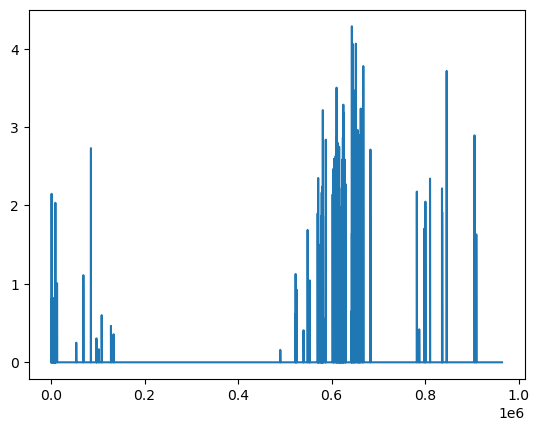

In [84]:
plt.plot(full_data_arr[:,-1])

In [ ]:
#trying 12 hour chunks (minutes)
m = 720
#predicting eruption in next day
n = 1440

#making array of starts to featurize next m minutes and label with n mins after that
size = full_data_arr.shape[0]
high_start = size - n - m #highest starting time for slice
starts = np.arange(high_start)[::m]
starts

array([     0,    720,   1440, ..., 961200, 961920, 962640], shape=(1338,))

In [79]:
#slicing dataset
X = np.zeros((len(starts),10800))
Y = np.zeros((len(starts)))
for i in range(len(starts)):
    #features
    X[i,:] = full_data_arr[starts[i]:starts[i]+m, 1:-1].reshape(-1)
    erup = full_data_arr[starts[i]+m:starts[i]+m+n,-1]
    if np.max(erup)>0:
        Y[i] = 1


In [85]:
print("data shape: ", X.shape)
print("label shape: ", Y.shape)

data shape:  (1338, 10800)
label shape:  (1338,)


In [99]:
#splitting up data 70% train, 20% val, 10% test
X_train, X_temp, Y_train, Y_temp = sklearn.model_selection.train_test_split(X,Y,test_size = 0.3, stratify = Y)
X_val, X_test, Y_val, Y_test = sklearn.model_selection.train_test_split(X_temp,Y_temp,test_size = 0.333333, stratify = Y_temp)

In [ ]:
#tree types: 'dart', 'gbdt', 'rf'

In [107]:
#training LightGBM
lgbm = lightgbm.LGBMClassifier(boosting_type = 'dart')
lgbm.fit(X_train, Y_train, eval_set=(X_val, Y_val))

[LightGBM] [Info] Number of positive: 108, number of negative: 828
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.225026 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1624826
[LightGBM] [Info] Number of data points in the train set: 936, number of used features: 9654
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.115385 -> initscore=-2.036882
[LightGBM] [Info] Start training from score -2.036882
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


,boosting_type,'dart'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [139]:
lgbm.score(X_val,Y_val)

/Users/harpersewalls/miniforge3/envs/volcano/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


0.8992537313432836

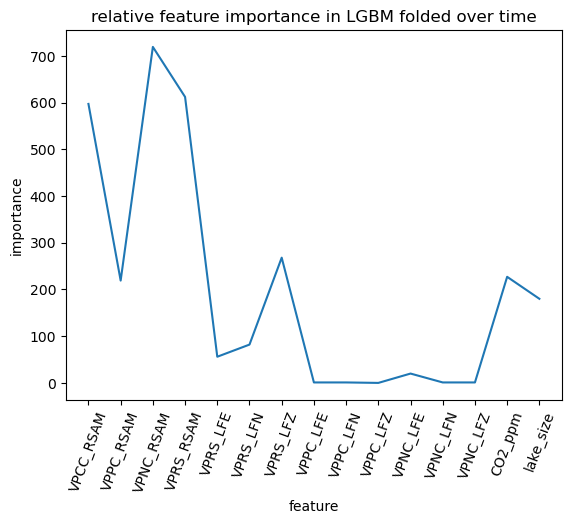

In [134]:
imp = lgbm.feature_importances_
folded = [0 for i in range(15)]
for i in range(len(imp)):
    folded[i%15] += imp[i]

plt.title("relative feature importance in LGBM folded over time")
plt.ylabel("importance")
plt.xlabel("feature")
plt.plot(folded)
plt.xticks(ticks = np.arange(15), labels = ['VPCC_RSAM', 'VPPC_RSAM', 'VPNC_RSAM', 'VPRS_RSAM',
       'VPRS_LFE', 'VPRS_LFN', 'VPRS_LFZ', 'VPPC_LFE', 'VPPC_LFN', 'VPPC_LFZ',
       'VPNC_LFE', 'VPNC_LFN', 'VPNC_LFZ', 'CO2_ppm','lake_size'], rotation = 70);

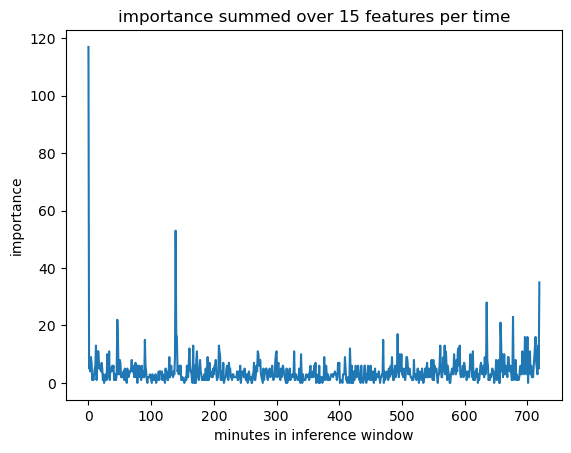

In [140]:
imp = lgbm.feature_importances_
folded = [0 for i in range(720)]
for i in range(len(folded)):
    folded[i] = np.sum(imp[15*i:15*(i+1)])

plt.title("importance summed over 15 features per time")
plt.ylabel("importance")
plt.xlabel("minutes in inference window")
plt.plot(folded)